## Comparsion to assess whether different computational frameworks converge on similar biological interaction patterns.

In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

### Load sample

In [2]:
commot_mat = pd.read_csv("/home/akram/share/Multiple_Grids/COMMOT/comparsion_output/COMMOT_celltype_matrix_MEAN_ALL_GRIDS.csv", index_col=0)
spaci_mat  = pd.read_csv("/home/akram/share/Multiple_Grids/spaCI/summary_results/spaCI_MEAN_interaction_matrix_ALL_GRIDS.csv", index_col=0)
spacia_mat = pd.read_csv("/home/akram/share/Multiple_Grids/Spacia/Results/Spacia_celltype_matrix.csv", index_col=0)
vgae_mat   = pd.read_csv("/home/akram/share/Multiple_Grids/VGAE_CCI/summary_results/VGAECCI_MEAN_celltype_matrix_ALL_GRIDS.csv", index_col=0)

In [3]:
def clean_matrix(mat):
    mat = mat.copy()
    mat.index = mat.index.astype(str)
    mat.columns = mat.columns.astype(str)
    mat = mat.apply(pd.to_numeric, errors="coerce")
    mat = mat.fillna(0)
    return mat

commot_mat = clean_matrix(commot_mat)
spaci_mat  = clean_matrix(spaci_mat)
spacia_mat = clean_matrix(spacia_mat)
vgae_mat   = clean_matrix(vgae_mat)

### Align all matrices to the same cell-type list

In [4]:
all_celltypes = sorted(
    set(commot_mat.index) | set(commot_mat.columns) |
    set(spaci_mat.index)  | set(spaci_mat.columns)  |
    set(spacia_mat.index) | set(spacia_mat.columns) |
    set(vgae_mat.index)   | set(vgae_mat.columns)
)

def align_matrix(mat, celltypes):
    return mat.reindex(index=celltypes, columns=celltypes, fill_value=0)

commot_mat = align_matrix(commot_mat, all_celltypes)
spaci_mat  = align_matrix(spaci_mat, all_celltypes)
spacia_mat = align_matrix(spacia_mat, all_celltypes)
vgae_mat   = align_matrix(vgae_mat, all_celltypes)

### Matrix normalize using min/max

In [5]:
def minmax_scale_matrix(mat):
    mat = mat.copy().astype(float)
    arr = mat.values
    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)

    if vmax == vmin:
        return mat * 0

    return (mat - vmin) / (vmax - vmin)

commot_scaled = minmax_scale_matrix(commot_mat)
spaci_scaled  = minmax_scale_matrix(spaci_mat)
spacia_scaled = minmax_scale_matrix(spacia_mat)
vgae_scaled   = minmax_scale_matrix(vgae_mat)

### Extract top strong cell-type pairs

In [6]:
def get_top_pairs(mat, top_n=10, remove_self=True):
    df = mat.stack().reset_index()
    df.columns = ["sender", "receiver", "score"]

    if remove_self:
        df = df[df["sender"] != df["receiver"]]

    df = df.sort_values("score", ascending=False).head(top_n).reset_index(drop=True)
    return df

In [7]:
top_n = 20

top_commot = get_top_pairs(commot_scaled, top_n=top_n, remove_self=True)
top_spaci  = get_top_pairs(spaci_scaled,  top_n=top_n, remove_self=True)
top_spacia = get_top_pairs(spacia_scaled, top_n=top_n, remove_self=True)
top_vgae   = get_top_pairs(vgae_scaled,   top_n=top_n, remove_self=True)

In [8]:
print("COMMOT top pairs:\n", top_commot, "\n")
print("spaCI top pairs:\n", top_spaci, "\n")
print("Spacia top pairs:\n", top_spacia, "\n")
print("VGAE-CCI top pairs:\n", top_vgae, "\n")

COMMOT top pairs:
                sender           receiver     score
0   Neuron-Inhibitory        Endothelial  1.000000
1           Astrocyte        Endothelial  0.925261
2   Neuron-Excitatory        Endothelial  0.835315
3     Oligodendrocyte        Endothelial  0.481378
4          Neuron-MSN        Endothelial  0.395666
5   Neuron-Inhibitory    Oligodendrocyte  0.375436
6   Neuron-Inhibitory          Astrocyte  0.309914
7   Neuron-Inhibitory         Neuron-MSN  0.258734
8   Neuron-Inhibitory  Neuron-Excitatory  0.257574
9   Neuron-Excitatory    Oligodendrocyte  0.256604
10         Neuron-MSN  Neuron-Inhibitory  0.217509
11  Neuron-Inhibitory           Pericyte  0.194684
12          Astrocyte  Neuron-Inhibitory  0.194130
13                OPC        Endothelial  0.183833
14  Neuron-Excitatory          Astrocyte  0.179168
15          Astrocyte    Oligodendrocyte  0.163033
16          Astrocyte           Pericyte  0.161034
17  Neuron-Inhibitory          Microglia  0.160754
18  Neuron-E

### Find dominant sender and receiver cell types

In [9]:
def dominant_celltypes(top_df):
    sender_counts = top_df["sender"].value_counts().rename("sender_count")
    receiver_counts = top_df["receiver"].value_counts().rename("receiver_count")
    return sender_counts, receiver_counts

In [10]:
for tool_name, top_df in {
    "COMMOT": top_commot,
    "spaCI": top_spaci,
    "Spacia": top_spacia,
    "VGAE-CCI": top_vgae
}.items():
    sender_counts, receiver_counts = dominant_celltypes(top_df)

    print(f"\n=== {tool_name} ===")
    print("Dominant senders:")
    print(sender_counts)
    print("\nDominant receivers:")
    print(receiver_counts)


=== COMMOT ===
Dominant senders:
sender
Neuron-Inhibitory    7
Astrocyte            4
Neuron-Excitatory    4
Oligodendrocyte      2
Neuron-MSN           2
OPC                  1
Name: sender_count, dtype: int64

Dominant receivers:
receiver
Endothelial          6
Oligodendrocyte      3
Neuron-Inhibitory    3
Pericyte             3
Astrocyte            2
Neuron-MSN           1
Neuron-Excitatory    1
Microglia            1
Name: receiver_count, dtype: int64

=== spaCI ===
Dominant senders:
sender
Pericyte      13
VLMC           4
Macrophage     3
Name: sender_count, dtype: int64

Dominant receivers:
receiver
Neuron-Excitatory    3
VSMC                 3
Neutrophil           3
Neuron-Inhibitory    1
Macrophage           1
VLMC                 1
Neuron-MSN           1
OPC                  1
Oligodendrocyte      1
Endothelial          1
B cell               1
T cell               1
Microglia            1
Pericyte             1
Name: receiver_count, dtype: int64

=== Spacia ===
Dominant sen

In [11]:
for tool_name, top_df in {
    "COMMOT": top_commot,
    "spaCI": top_spaci,
    "Spacia": top_spacia,
    "VGAE-CCI": top_vgae
}.items():
    sender_counts, receiver_counts = dominant_celltypes(top_df)

    sender_counts.to_csv(f"/home/akram/share/Multiple_Grids/Comparsion_output/{tool_name}_dominant_senders.csv")
    receiver_counts.to_csv(f"/home/akram/share/Multiple_Grids/Comparsion_output/{tool_name}_dominant_receivers.csv")

### Compare overlap of strong pairs between tools

In [12]:
def pair_set(top_df):
    return set(zip(top_df["sender"], top_df["receiver"]))

tool_top_pairs = {
    "COMMOT": top_commot,
    "spaCI": top_spaci,
    "Spacia": top_spacia,
    "VGAE-CCI": top_vgae
}

overlap_results = []

for t1, t2 in combinations(tool_top_pairs.keys(), 2):
    pairs1 = pair_set(tool_top_pairs[t1])
    pairs2 = pair_set(tool_top_pairs[t2])
    shared = pairs1 & pairs2

    overlap_results.append({
        "tool_1": t1,
        "tool_2": t2,
        "n_shared_pairs": len(shared),
        "shared_pairs": "; ".join([f"{a}->{b}" for a, b in sorted(shared)])
    })

overlap_df = pd.DataFrame(overlap_results)
print(overlap_df)
overlap_df.to_csv("/home/akram/share/Multiple_Grids/Comparsion_output/top_pairs_overlap.csv", index=False)

   tool_1    tool_2  n_shared_pairs  \
0  COMMOT     spaCI               0   
1  COMMOT    Spacia               6   
2  COMMOT  VGAE-CCI               0   
3   spaCI    Spacia               1   
4   spaCI  VGAE-CCI               4   
5  Spacia  VGAE-CCI               0   

                                        shared_pairs  
0                                                     
1  Astrocyte->Neuron-Inhibitory; Astrocyte->Oligo...  
2                                                     
3                          Pericyte->Oligodendrocyte  
4  Macrophage->Neutrophil; Macrophage->VSMC; Peri...  
5                                                     


### Side-by-Side Heatmaps
shows:

    - Overall interaction patterns
    - Visual comparison of strong vs weak regions

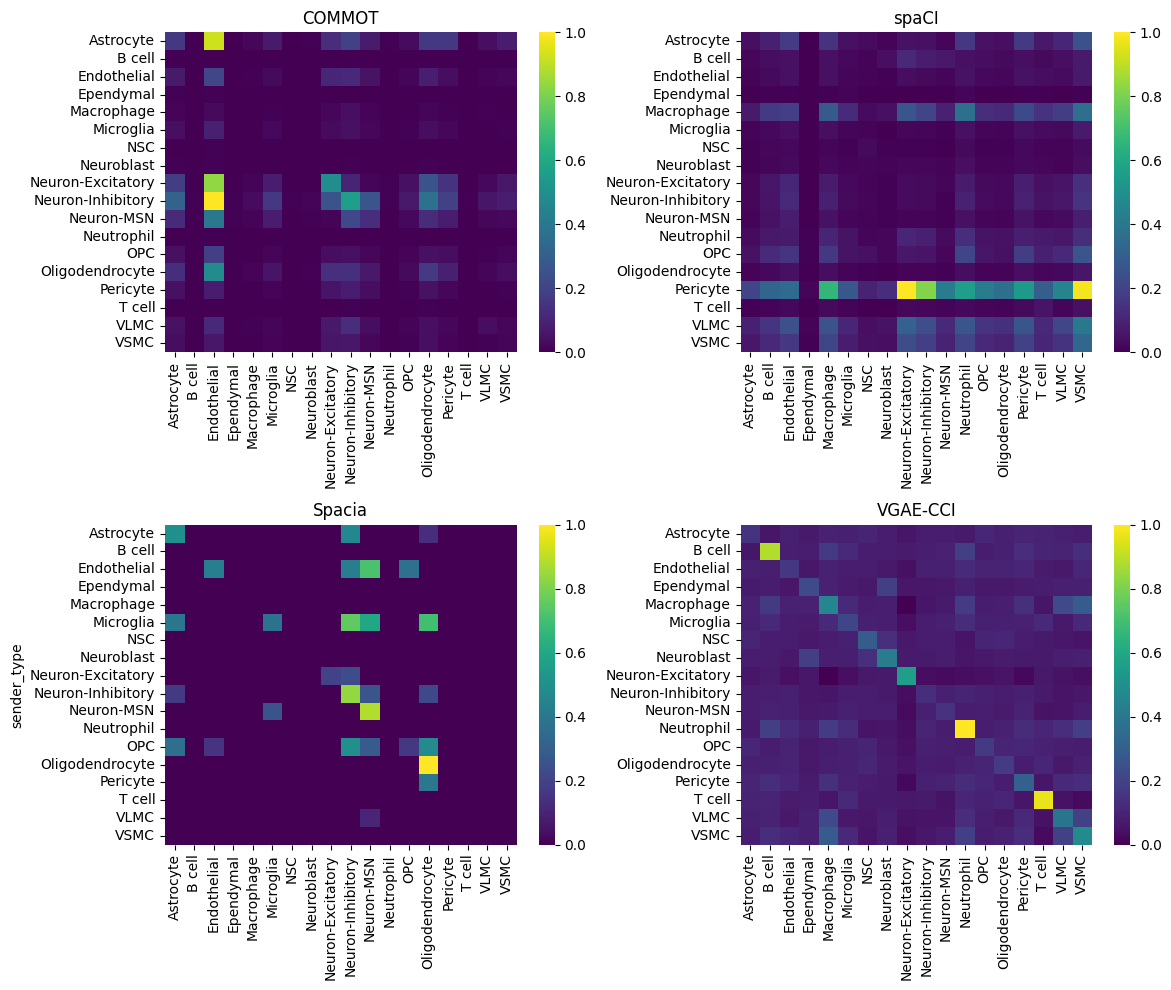

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(commot_scaled, ax=axes[0,0], cmap="viridis")
axes[0,0].set_title("COMMOT")

sns.heatmap(spaci_scaled, ax=axes[0,1], cmap="viridis")
axes[0,1].set_title("spaCI")

sns.heatmap(spacia_scaled, ax=axes[1,0], cmap="viridis")
axes[1,0].set_title("Spacia")

sns.heatmap(vgae_scaled, ax=axes[1,1], cmap="viridis")
axes[1,1].set_title("VGAE-CCI")

plt.tight_layout()
plt.show()

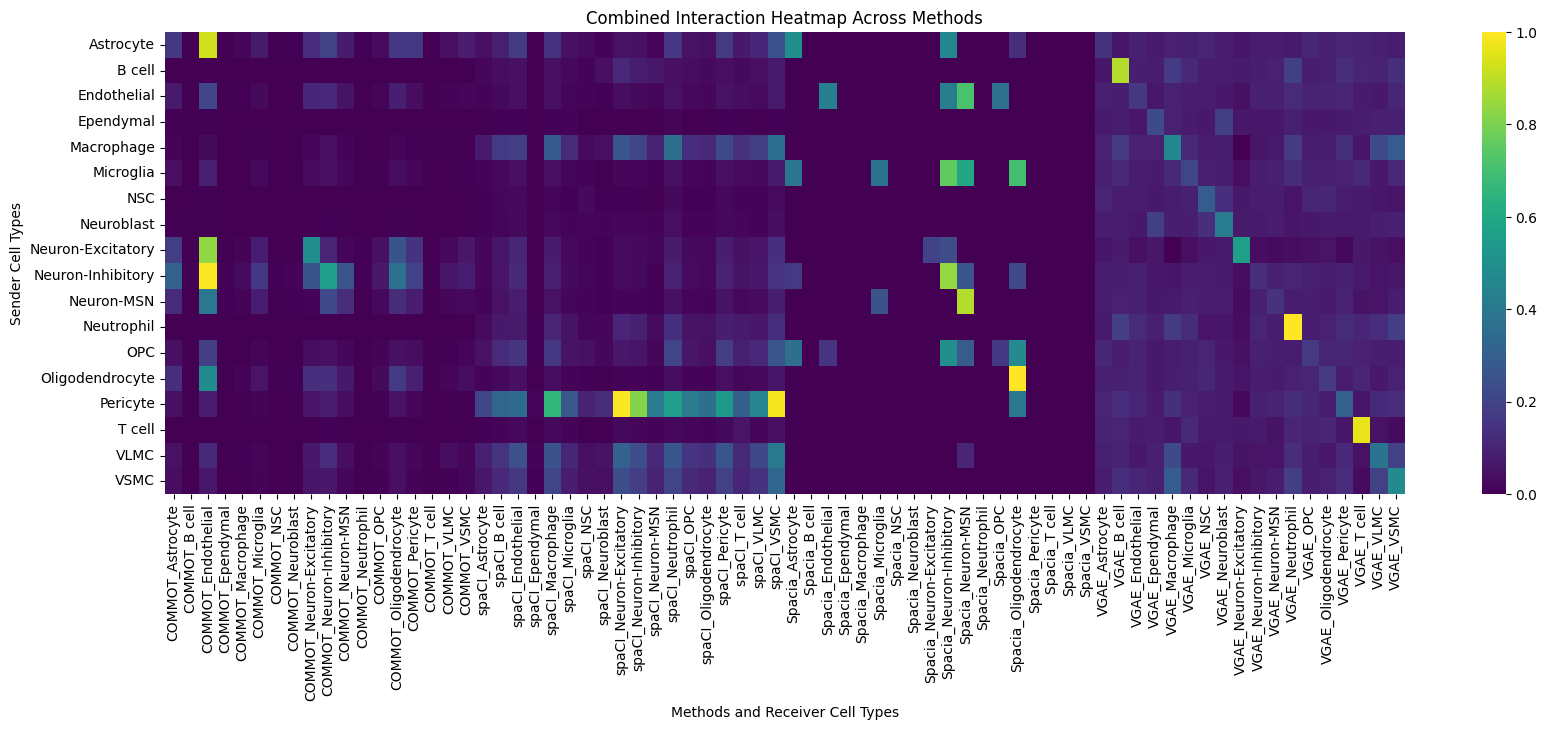

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Make sure same order
cell_order = commot_scaled.index

commot = commot_scaled.loc[cell_order, cell_order]
spaci  = spaci_scaled.loc[cell_order, cell_order]
spacia = spacia_scaled.loc[cell_order, cell_order]
vgae   = vgae_scaled.loc[cell_order, cell_order]

# 2. Rename columns so we know which tool
commot.columns = ["COMMOT_" + str(c) for c in commot.columns]
spaci.columns  = ["spaCI_" + str(c) for c in spaci.columns]
spacia.columns = ["Spacia_" + str(c) for c in spacia.columns]
vgae.columns   = ["VGAE_" + str(c) for c in vgae.columns]

# 3. Combine into ONE matrix
combined = pd.concat([commot, spaci, spacia, vgae], axis=1)

# 4. Plot ONE heatmap
plt.figure(figsize=(20,6))
sns.heatmap(combined, cmap="viridis", vmin=0, vmax=1)

plt.title("Combined Interaction Heatmap Across Methods")
plt.xlabel("Methods and Receiver Cell Types")
plt.ylabel("Sender Cell Types")

plt.show()

#### The comparison of cell-type interaction heatmaps revealed substantial differences across methods. COMMOT highlighted strong interactions primarily involving excitatory neurons, reflecting its spatially informed signaling model. In contrast, spaCI identified Pericytes as a dominant sender cell type, likely driven by high ligand expression levels. Spacia produced a sparse interaction pattern, retaining only statistically significant interactions, while VGAE-CCI exhibited more distributed patterns reflecting global cell similarity rather than specific signaling mechanisms. Overall, limited overlap was observed across methods, indicating that each tool captures distinct aspects of cell–cell communication.

### Strongest interactions per tool

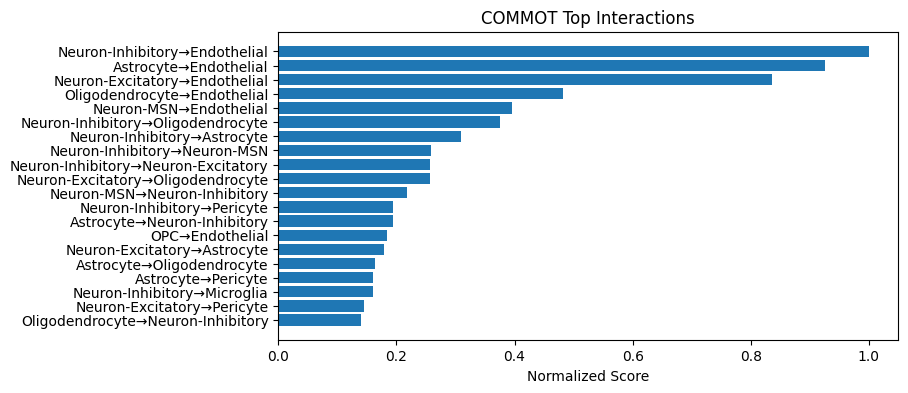

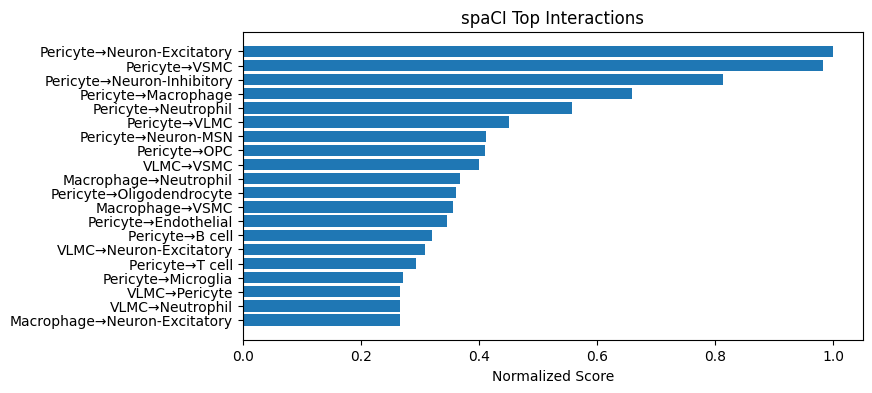

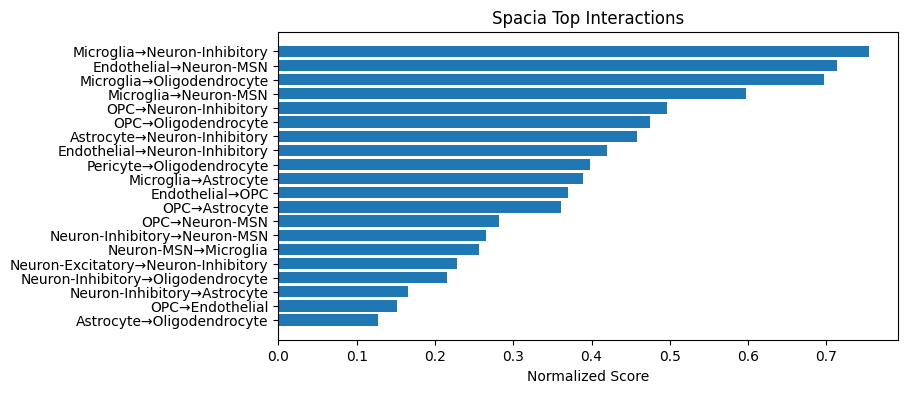

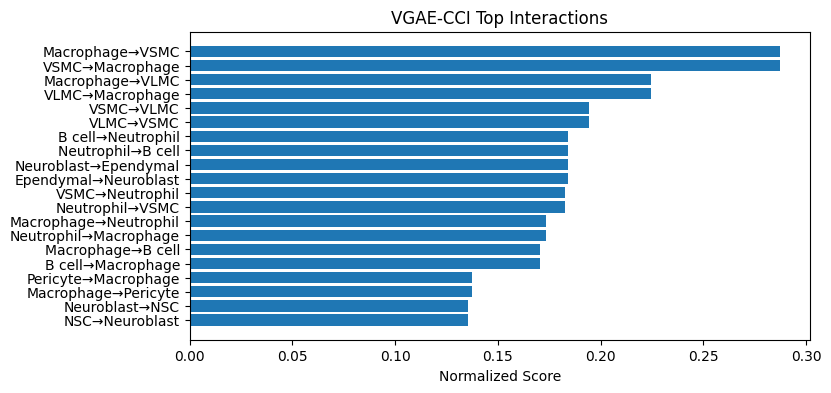

In [15]:
def plot_top_pairs(top_df, title):
    labels = top_df["sender"] + "→" + top_df["receiver"]
    
    plt.figure(figsize=(8,4))
    plt.barh(labels[::-1], top_df["score"][::-1])
    plt.title(title)
    plt.xlabel("Normalized Score")
    plt.show()

plot_top_pairs(top_commot, "COMMOT Top Interactions")
plot_top_pairs(top_spaci, "spaCI Top Interactions")
plot_top_pairs(top_spacia, "Spacia Top Interactions")
plot_top_pairs(top_vgae, "VGAE-CCI Top Interactions")

### Overlap Plot (Jaccard / Intersection Heatmap)

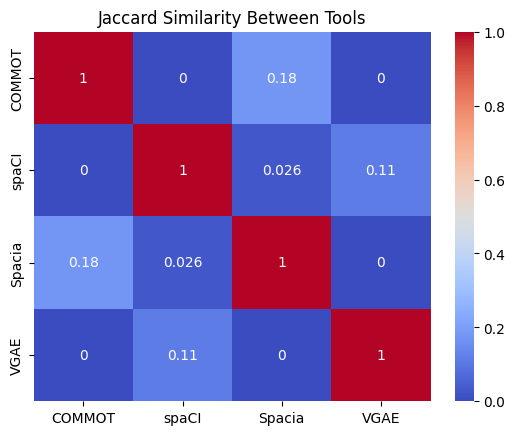

In [16]:
def jaccard(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

tools = {
    "COMMOT": set(zip(top_commot["sender"], top_commot["receiver"])),
    "spaCI": set(zip(top_spaci["sender"], top_spaci["receiver"])),
    "Spacia": set(zip(top_spacia["sender"], top_spacia["receiver"])),
    "VGAE": set(zip(top_vgae["sender"], top_vgae["receiver"]))
}

names = list(tools.keys())
matrix = pd.DataFrame(index=names, columns=names)

for i in names:
    for j in names:
        matrix.loc[i,j] = jaccard(tools[i], tools[j])

matrix = matrix.astype(float)

sns.heatmap(matrix, annot=True, cmap="coolwarm")
plt.title("Jaccard Similarity Between Tools")
plt.show()

### The low agreement suggests that cell–cell communication inference remains an open challenge, and combining multiple methods may be necessary to obtain a more comprehensive view of intercellular signaling.

### Dominant Cell-Type Plot

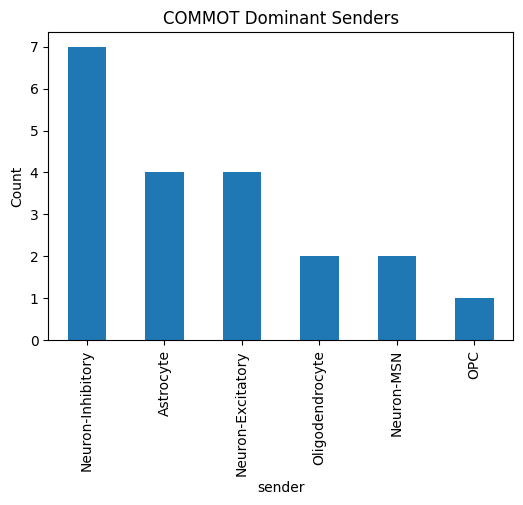

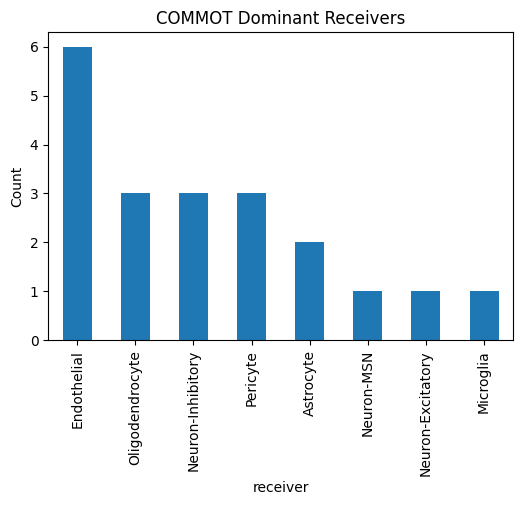

In [17]:
def plot_dominant(counts, title):
    counts.plot(kind="bar", figsize=(6,4))
    plt.title(title)
    plt.ylabel("Count")
    plt.show()

sender_counts, receiver_counts = dominant_celltypes(top_commot)
plot_dominant(sender_counts, "COMMOT Dominant Senders")
plot_dominant(receiver_counts, "COMMOT Dominant Receivers")

## Network Graph

### Node size = degree (number of interactions) or sum of interaction scores for that cell type.
### Edge thickness = interaction strength (normalized)
### Edge Sender → Receiver

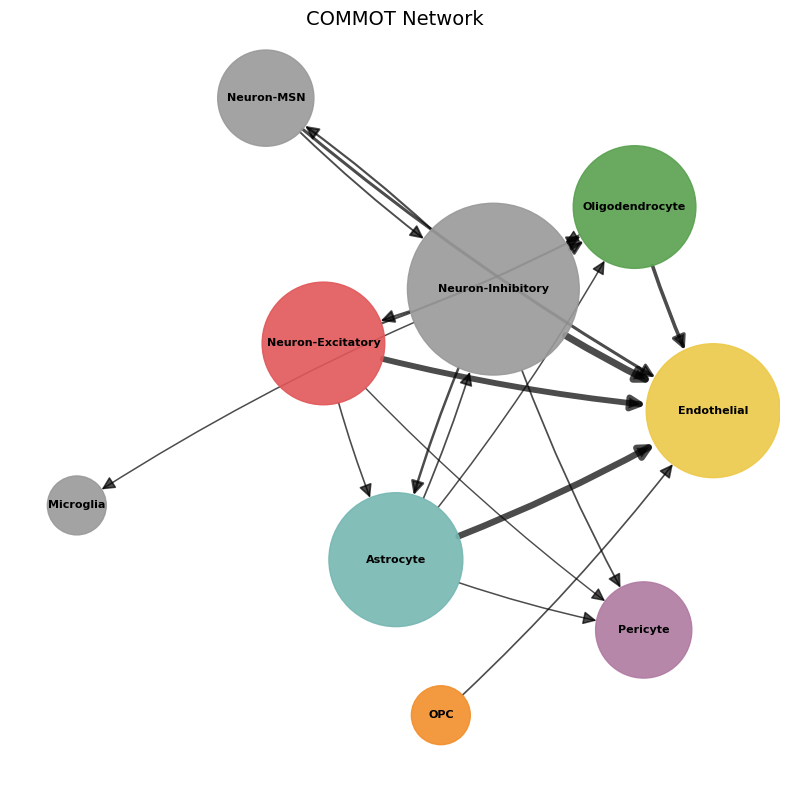

In [19]:
def plot_network(top_df, title):
    G = nx.DiGraph()
    
    # Add edges
    for _, row in top_df.iterrows():
        G.add_edge(row["sender"], row["receiver"], weight=row["score"])
    
    plt.figure(figsize=(8, 8))
    
    # Layout
    pos = nx.spring_layout(G, k=2.8, iterations=100, seed=42)
    
    # 🎨 Node colors
    color_map = {
        "Neuron-Excitatory": "#E15759",
        "Astrocyte": "#76B7B2",
        "Oligodendrocyte": "#59A14F",
        "OPC": "#F28E2B",
        "Endothelial": "#EDC948",
        "Pericyte": "#B07AA1",
        "VSMC": "#FF9DA7"
    }
    
    node_colors = [color_map.get(n, "#999999") for n in G.nodes()]
    
    # Node sizes (degree-based)
    node_sizes = [300 + 1500 * G.degree(n) for n in G.nodes()]
    
    # 🔥 Normalize edge widths
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    w_min, w_max = min(weights), max(weights)
    
    edge_widths = [
        1 + 4 * (w - w_min) / (w_max - w_min) if w_max > w_min else 2
        for w in weights
    ]
    
    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.9
    )
    
    # Draw edges (FIXED attachment + clean arrows)
    nx.draw_networkx_edges(
        G, pos,
        width=edge_widths,
        alpha=0.7,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=20,
        node_size=node_sizes,  # ⭐ ensures edges stop at node boundary
        connectionstyle="arc3,rad=0.05"
    )
    
    # Labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=8,
        font_weight="bold"
    )
    
    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Optional: filter weak edges
# top_spacia = top_spacia[top_spacia["score"] > 0.2]

plot_network(top_commot, "COMMOT Network")

In [ ]:
plot_network(top_spacia, "Spacia Network")

In [ ]:
plot_network(top_spaci, "spaCI Network")

In [ ]:
plot_network(top_vgae, "VGAE Network")

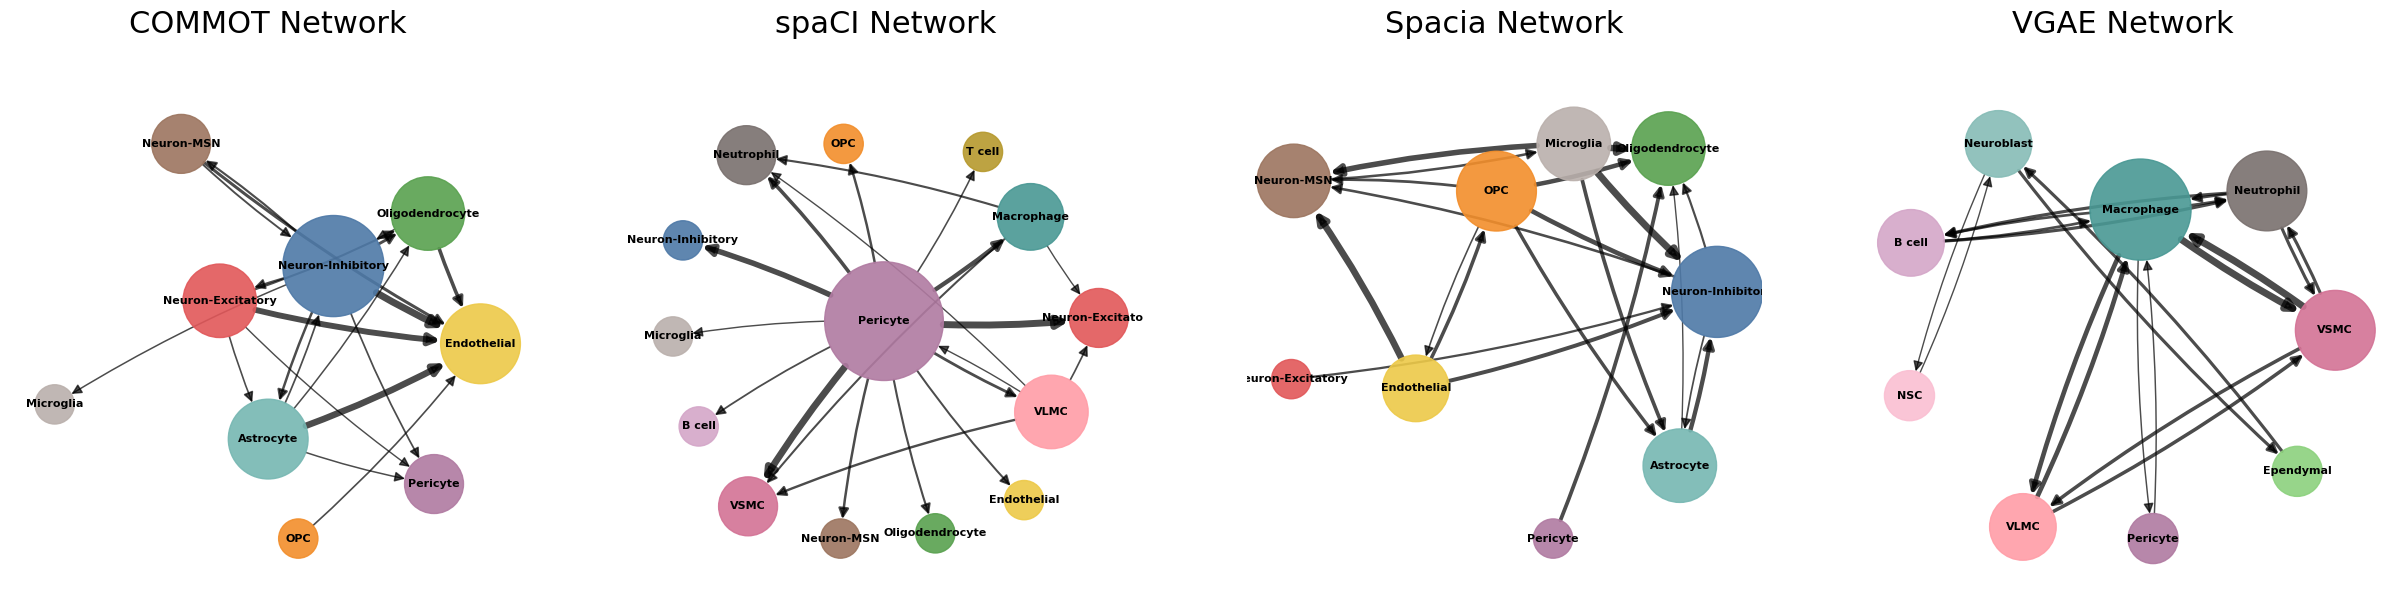

In [20]:
def plot_network(ax, top_df, title):
    G = nx.DiGraph()

    for _, row in top_df.iterrows():
        G.add_edge(row["sender"], row["receiver"], weight=row["score"])

    pos = nx.spring_layout(G, k=2.8, iterations=100, seed=42)

    
    color_map = {
    "Neuron-Inhibitory": "#4E79A7",
    "Neuron-Excitatory": "#E15759",
    "Oligodendrocyte": "#59A14F",
    "Astrocyte": "#76B7B2",
    "Neuron-MSN": "#9C755F",
    "Endothelial": "#EDC948",
    "Microglia": "#BAB0AC",
    "OPC": "#F28E2B",
    "Pericyte": "#B07AA1",
    "VLMC": "#FF9DA7",
    "VSMC": "#D37295",
    "Ependymal": "#8CD17D",
    "Macrophage": "#499894",
    "Neuroblast": "#86BCB6",
    "NSC": "#FABFD2",
    "Neutrophil": "#79706E",
    "T cell": "#B6992D",
    "B cell": "#D4A6C8"
}
    
    node_colors = [color_map.get(n, "#999999") for n in G.nodes()]
    node_sizes = [300 + 500 * G.degree(n) for n in G.nodes()]

    weights = [G[u][v]['weight'] for u, v in G.edges()]
    w_min, w_max = min(weights), max(weights)

    edge_widths = [
        1 + 4 * (w - w_min) / (w_max - w_min) if w_max > w_min else 2
        for w in weights
    ]

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        width=edge_widths,
        alpha=0.7,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=15,
        node_size=node_sizes,
        connectionstyle="arc3,rad=0.05"
    )

    nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_size=8,
        font_weight="bold"
    )

    ax.set_title(title, fontsize=22 , pad=50)
    ax.axis("off")


# ---- ONE ROW FIGURE ----
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

plot_network(axes[0], top_commot, "COMMOT Network")
plot_network(axes[1], top_spaci, "spaCI Network")
plot_network(axes[2], top_spacia, "Spacia Network")
plot_network(axes[3], top_vgae, "VGAE Network")

plt.tight_layout()
plt.subplots_adjust(wspace=0.2) 
plt.show()